In [1]:
from keras.preprocessing.image import ImageDataGenerator

In [2]:
import tensorflow as tf

In [3]:
import numpy as np
from matplotlib import pyplot as plt

In [4]:
data = 'data_set'

In [6]:
image_generator = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True, validation_split=0.3)
train_data_gen = image_generator.flow_from_directory(directory=data,
                                                    target_size = (256, 256),
                                                    batch_size = 32,
                                                    class_mode = 'categorical',
                                                    subset = 'training')
val_data_gen = image_generator.flow_from_directory(directory=data,
                                                    target_size = (256, 256),
                                                    batch_size = 16,
                                                    class_mode = 'categorical',
                                                    subset = 'validation')

Found 323 images belonging to 7 classes.
Found 134 images belonging to 7 classes.


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [9]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Dense(22, activation='relu', input_shape=[256, 256, 3]))

model.add(tf.keras.layers.Conv2D(128, kernel_size=[3,3], padding='valid', activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=[3,3], strides=2, padding='valid'))

model.add(tf.keras.layers.Conv2D(64, kernel_size=[3,3], padding='valid', activation='relu'))                                                  
model.add(tf.keras.layers.MaxPooling2D(pool_size=[3,3], strides=2, padding='valid'))

model.add(tf.keras.layers.Conv2D(32, kernel_size=[3,3], padding='valid', activation='relu')) 
model.add(tf.keras.layers.MaxPooling2D(pool_size=[3,3], strides=2, padding='valid'))

model.add(tf.keras.layers.Conv2D(32, kernel_size=[3,3], padding='valid', activation='relu')) 
model.add(tf.keras.layers.MaxPooling2D(pool_size=[3,3], strides=2, padding='valid'))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(7, activation='softmax'))  # Adjusted to have 7 units for 7 classes

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 256, 256, 22)      88        
                                                                 
 conv2d_4 (Conv2D)           (None, 254, 254, 128)     25472     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 126, 126, 128)     0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 124, 124, 64)      73792     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 61, 61, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 59, 59, 32)       

In [10]:
hist = model.fit(train_data_gen, validation_data=val_data_gen, epochs=20, verbose=2)

Epoch 1/20
11/11 - 33s - loss: 12.4603 - accuracy: 0.2260 - val_loss: 2.5308 - val_accuracy: 0.4254 - 33s/epoch - 3s/step
Epoch 2/20
11/11 - 33s - loss: 3.1349 - accuracy: 0.2724 - val_loss: 2.1410 - val_accuracy: 0.1791 - 33s/epoch - 3s/step
Epoch 3/20
11/11 - 32s - loss: 2.0316 - accuracy: 0.3065 - val_loss: 1.8390 - val_accuracy: 0.3881 - 32s/epoch - 3s/step
Epoch 4/20
11/11 - 32s - loss: 1.7960 - accuracy: 0.3808 - val_loss: 1.8035 - val_accuracy: 0.3881 - 32s/epoch - 3s/step
Epoch 5/20
11/11 - 34s - loss: 1.7560 - accuracy: 0.3870 - val_loss: 1.7457 - val_accuracy: 0.3955 - 34s/epoch - 3s/step
Epoch 6/20
11/11 - 38s - loss: 1.7920 - accuracy: 0.3684 - val_loss: 1.8405 - val_accuracy: 0.3955 - 38s/epoch - 3s/step
Epoch 7/20
11/11 - 37s - loss: 1.7840 - accuracy: 0.3746 - val_loss: 1.8097 - val_accuracy: 0.3806 - 37s/epoch - 3s/step
Epoch 8/20
11/11 - 32s - loss: 1.6685 - accuracy: 0.3901 - val_loss: 1.7820 - val_accuracy: 0.4030 - 32s/epoch - 3s/step
Epoch 9/20
11/11 - 32s - loss: 

In [11]:
hist.history

{'loss': [12.460282325744629,
  3.1349122524261475,
  2.031623125076294,
  1.7960327863693237,
  1.7559882402420044,
  1.7920492887496948,
  1.7840182781219482,
  1.6684744358062744,
  1.6257798671722412,
  1.6766706705093384,
  1.5213279724121094,
  1.4349836111068726,
  1.4126002788543701,
  1.3019555807113647,
  1.3052728176116943,
  1.3249285221099854,
  1.2365652322769165,
  1.1497740745544434,
  1.1455820798873901,
  1.0997326374053955],
 'accuracy': [0.22600619494915009,
  0.27244582772254944,
  0.3065015375614166,
  0.38080495595932007,
  0.38699689507484436,
  0.3684210479259491,
  0.3746130168437958,
  0.3900928795337677,
  0.42105263471603394,
  0.41486069560050964,
  0.42105263471603394,
  0.48606809973716736,
  0.48606809973716736,
  0.5510835647583008,
  0.5386996865272522,
  0.5386996865272522,
  0.5665634870529175,
  0.5789473652839661,
  0.5820433497428894,
  0.62848299741745],
 'val_loss': [2.5307729244232178,
  2.140953779220581,
  1.8390082120895386,
  1.80348706245

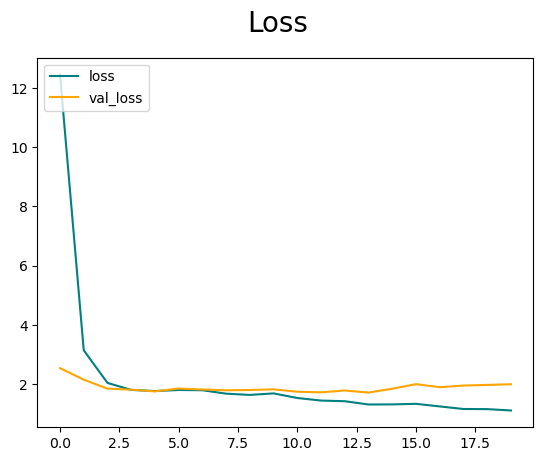

In [12]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

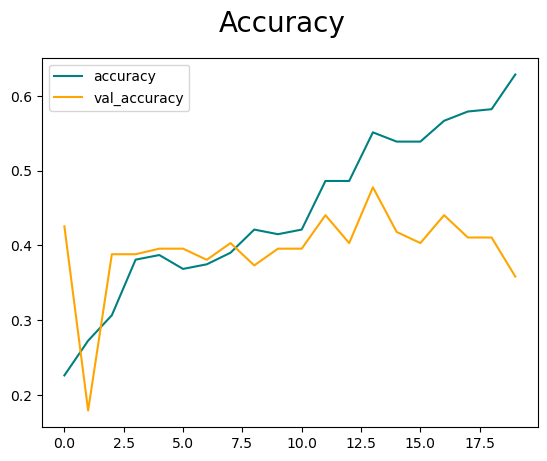

In [13]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

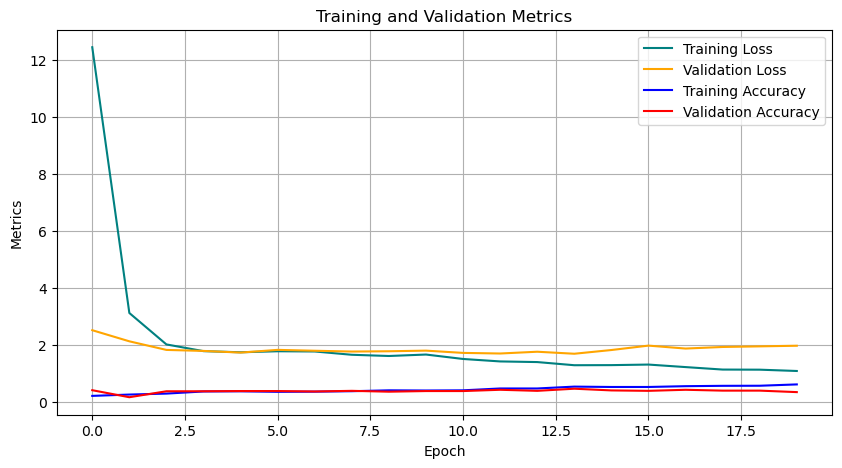

In [14]:
import matplotlib.pyplot as plt

# Plot loss and accuracy on the same graph
plt.figure(figsize=(10, 5))

# Plot loss
plt.plot(hist.history['loss'], color='teal', label='Training Loss')
plt.plot(hist.history['val_loss'], color='orange', label='Validation Loss')

# Plot accuracy
plt.plot(hist.history['accuracy'], color='blue',  label='Training Accuracy')
plt.plot(hist.history['val_accuracy'], color='red', label='Validation Accuracy')

plt.title('Training and Validation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.legend()
plt.grid(True)
plt.show()


In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming model is your trained ConvLSTM model
# Assuming features_test contains test data and labels_test contains true labels
# Replace features_test and labels_test with your actual test data and true labels
y_pred = model.predict(train_data_gen)
y_true = val_data_gen.argmax(axis=1)  # Convert one-hot encoded labels back to integers

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred.argmax(axis=1))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


11/11 [==============================] - 7s 592ms/step


AttributeError: 'DirectoryIterator' object has no attribute 'argmax'